# FX pairs: regularizing when the cross-section itself is dependent

The 20 pairs in this universe are not 20 independent assets. They are quotes between eight
currencies, so `EUR_USD`, `GBP_USD` and `EUR_GBP` are related by an accounting identity: hold
the first two in the right proportions and you have the third. A dollar move shows up in every
pair with USD on one side, in the same direction, at the same moment.

That is a different problem from a collinear feature set, and it is worth separating the two.
**Collinear features** are columns of the design matrix that carry nearly the same information,
and this universe has those too - seven return windows, eight volatility windows, seven rolling
Sharpe ratios, and eight cross-sectional ranks computed from them. **A dependent cross-section**
is something else: the rows are linked, so ranking the pairs against each other is ranking
overlapping bets rather than distinct ones. A model that discovers "the dollar is strong" scores
well on the ranking and has found one fact, not twenty.

**Regularization** - adding a penalty on coefficient size to the fitting objective - addresses
the first problem directly and the second not at all. This notebook runs the penalty sweep and
the results are read with that distinction in mind.

**Learning objectives.** By the end of this notebook you will be able to:

- Read the set of models a case study has declared for a label, and say which estimator and
  which hyperparameters each declared name resolves to.
- Bind those declarations to the data on disk and check, before anything is fitted, that every
  configuration will be measured on the same pairs, the same dates and the same folds.
- Fit a population of models on walk-forward folds and publish one complete set of validation
  predictions per configuration.
- Tell apart the two things a penalty can do to a correlated feature set - shrink correlated
  coefficients towards each other, or select a few features and zero the rest - and read from
  the results which one this data rewards.
- Distinguish collinearity among the features from dependence among the assets being ranked,
  and say which one a penalty can fix.
- Run configurations of your own into a private copy of the run log, and have them compared on
  the same footing as the ones shipped here.

**Book reference**: Chapter 11 (The ML Pipeline). Chapter 6, Section 6.7 (Search accounting and
run logging) introduces the run log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
and [`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds.

**What it writes**: one training run and one complete validation prediction set per
configuration, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a named population.
[`13_backtest`](13_backtest.ipynb) reads that population, runs every member against the
equal-weight baseline, and selects on validation backtest Sharpe. **Selection happens there,
not here.** This notebook ranks configurations by information coefficient to show what
regularization does to a correlated feature set; that ranking decides nothing.

In [1]:
"""Fit the declared FX linear-model population on the walk-forward validation folds."""

import re

import numpy as np
import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABEL = "fwd_ret_1d"
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = "fx_pairs-linear-validation-v1"

In [3]:
study = open_study("fx_pairs", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

## 1. Which label, and which models

A label is the thing being predicted. This case study defines three in `config/setup.yaml`:
`fwd_ret_1d`, the return over the trading day after the decision date, and `fwd_ret_5d` and
`fwd_ret_21d` over longer horizons. The one-day label is the primary one - the horizon the
strategy chapters trade - and the other two are variants, kept so the effect of the prediction
horizon can be examined separately.

**This notebook fits one label per run.** `LABEL` above selects it, and every choice below
follows from that one setting, because each label has its own training menu at
`config/training/{label}.yaml`. The menu lists, family by family, the named configurations to
fit for that label. A label with no menu file has nothing declared and nothing to fit; these
are the ones that declare linear models.

In [4]:
declared_labels(study, "linear")

('fwd_ret_1d', 'fwd_ret_21d', 'fwd_ret_5d')

Each name in the menu resolves to a preset file in the shared directory
`case_studies/config/{model_type}/`, which holds that configuration's hyperparameters. The
frame below is the menu for `LABEL`, with each name resolved to the estimator class it names
and the arguments that class is constructed with. To change what runs, edit the menu or the
presets rather than this notebook.

The grid covers the two shapes a penalty can take:

- **Ridge** penalizes the sum of squared coefficients. It shrinks correlated coefficients
  towards each other and keeps every feature, at a strength set by `alpha`. The grid steps
  `alpha` by powers of ten across ten orders of magnitude, because the useful value depends on
  the scale and the collinearity of the design matrix and neither is known in advance.
- **Lasso** penalizes the sum of absolute coefficients, which drives some of them exactly to
  zero: it selects features rather than shrinking them. **ElasticNet** mixes the two.

Lasso and ElasticNet are parameterized here by `alpha_frac` rather than a raw penalty. For any
fold there is a threshold penalty $\alpha_{\max}$ - the smallest one that zeros every
coefficient - which is computed from that fold's own data. `alpha_frac` is the fraction of it
to apply, so one declared `alpha_frac` means the same thing on every fold, while a fixed raw
penalty would mean something different on each.

In [5]:
configs = load_model_configs(
    study,
    "linear",
    labels=[LABEL],
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""linear""","""fwd_ret_1d""","""ols""","""LinearRegression""","""defaults"""
"""linear""","""fwd_ret_1d""","""ridge_a0.001""","""Ridge""","""alpha=0.001"""
"""linear""","""fwd_ret_1d""","""ridge_a0.01""","""Ridge""","""alpha=0.01"""
"""linear""","""fwd_ret_1d""","""ridge_a0.1""","""Ridge""","""alpha=0.1"""
"""linear""","""fwd_ret_1d""","""ridge_a1.0""","""Ridge""","""alpha=1.0"""
…,…,…,…,…
"""linear""","""fwd_ret_1d""","""enet_f0.03""","""ElasticNet""","""alpha_frac=0.03, l1_ratio=0.5,…"
"""linear""","""fwd_ret_1d""","""enet_f0.015""","""ElasticNet""","""alpha_frac=0.015, l1_ratio=0.5…"
"""linear""","""fwd_ret_1d""","""enet_f0.35""","""ElasticNet""","""alpha_frac=0.35, l1_ratio=0.5,…"


## 2. Binding the declarations to the data

A menu entry says which estimator to fit. It does not say which feature columns exist today,
where the walk-forward folds fall, or which pair-date pairs have both a feature row and a
label. **Resolving** a request is the step that goes and finds all of that: it reads the label
and feature files, computes the fold boundaries from the walk-forward parameters in
`config/setup.yaml`, works out the exact set of rows each fit is expected to predict, and turns
any data-dependent hyperparameter into the number it will actually use - each fold's own
$\alpha_{\max}$ times `alpha_frac`, in the case of Lasso.

Resolving reads the inputs and fits nothing, so the plan below can be inspected before any
computation starts. The three things to check in it:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row.** They are
  the width of the design matrix, the number of currency pairs, and the number of pair-date
  pairs to be predicted. Every configuration here reads the same feature matrix, so a row that
  differs is a configuration being measured on a different sample from its neighbours, and its
  results are not comparable with theirs.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits
  `05_evaluation` established.
- **`validation_start` and `validation_end` bracket the development sample.** The held-out tail
  must not appear here: it is scored once, at the end of the case study, and any of it visible
  in this window would mean it had been used to choose something.

Each row also carries a `training_hash`: the identity of that computation, derived from
everything that can change its result. [`RUN_LOG.md`](../RUN_LOG.md#identity) sets out what goes
into one and what follows from it.

In [6]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "validation_start",
    "validation_end",
)

config_name,feature_count,eligible_entities,eligible_rows,folds,validation_start,validation_end
str,i64,i64,i64,i64,date,date
"""enet_f0.015""",63,20,41260,8,2016-01-05,2023-12-28
"""enet_f0.03""",63,20,41260,8,2016-01-05,2023-12-28
"""enet_f0.08""",63,20,41260,8,2016-01-05,2023-12-28
"""enet_f0.2""",63,20,41260,8,2016-01-05,2023-12-28
"""enet_f0.35""",63,20,41260,8,2016-01-05,2023-12-28
…,…,…,…,…,…,…
"""ridge_a1000.0""",63,20,41260,8,2016-01-05,2023-12-28
"""ridge_a10000.0""",63,20,41260,8,2016-01-05,2023-12-28
"""ridge_a100000.0""",63,20,41260,8,2016-01-05,2023-12-28


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. fills missing feature values with the training window's median for that column, then
   standardizes each column to zero mean and unit variance - both fitted on training rows only
   and then applied to the validation rows, so nothing from the validation window reaches the
   fit,
3. fits the estimator with that fold's resolved parameters,
4. predicts the fold's validation rows.

The fold predictions are concatenated into one series covering the whole validation period,
which is what a walk-forward prediction set is: each date predicted by a model that saw only
data before it. The run then writes a `training_runs` row and the fitted coefficients, a
`prediction_sets` row and the predictions themselves, and the metrics computed from them. It
does this per configuration rather than once at the end, so an interruption costs the
configuration in flight and nothing else.

Every case study that fits linear models calls this same runner, which is what makes their
results comparable. Unlike gradient boosting or a neural network, a linear model has no
intermediate states worth scoring: there is one fit and therefore one checkpoint per
configuration, and no learning curve to plot.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
is going to produce. The list is computed from the resolved specifications before the first fit
and written down, and afterwards every member must exist and be complete. That is what makes
the downstream comparison well defined - `13_backtest` backtests this population, not whatever
predictions happen to be in the registry - and it is why a configuration that raises fails the
whole call rather than publishing a population one member short. Everything that finished stays
registered, and re-running fits only what is missing.

In [7]:
execution, population = run_model_population(study, resolved, population_name=POPULATION_NAME)

fitted = sum(len(item["fitted_folds"]) for item in execution.diagnostics)
reused = sum(len(item["reused_folds"]) for item in execution.diagnostics)
print(f"{len(execution.runs)} configurations: {fitted} folds fitted, {reused} reused")
print(f"population {population.name}: {len(population.members)} prediction sets")

28 configurations: 0 folds fitted, 224 reused
population fx_pairs-linear-validation-v1: 28 prediction sets


`reused` is not zero on a second run. Every identity is re-derived from the inputs, the
registry already holds the matching rows, and the runner returns the stored result rather than
fitting again - so re-running this notebook unchanged costs the time it takes to read the data.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which
holds its own registry and artifacts and reads the same labels and features:

```python
study = open_study("fx_pairs", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "linear", labels=["fwd_ret_1d"], config_names=["ols", "ridge_a1.0", "ridge_a3.0"]
)
requests = model_requests(study, configs)
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-linear-v1")
```

`CONFIG_NAMES` fits a subset of what the menu already declares; a name the menu does not
declare raises rather than quietly fitting fewer models than you asked for. To fit something
new, add a preset at `case_studies/config/ridge/ridge_a3.0.yaml` and list `ridge_a3.0` under
`linear:` in the label's menu. Editing an existing preset changes that configuration's
identity, so its result registers as a new row beside the old one instead of replacing it.

Give the run its own `population_name`: a name refers to one set of members permanently, and
reusing it for a different set raises. Everything downstream reads the registry rather than the
notebook, so predictions produced this way are selected and backtested on the same footing as
the ones shipped here, inside your workspace.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest, including how to
rehearse on a reduced universe first.

## 4. What came out

One row per configuration, read back from the registry. `ic_mean` is the **information
coefficient**: on each validation date, rank the pairs by the model's prediction, rank them by
the return they went on to earn, correlate the two rankings, and average that daily correlation
over the validation period. It measures whether the model ranks pairs correctly, on a scale
where zero is no relationship, positive means the ranking points the right way, and negative
means it points the wrong way.

`ic_n_days` is how many validation dates produced a defined correlation, and it is not a
footnote. A model whose coefficients collapse to one or two features predicts nearly the same
value for every pair on some dates; a constant has no rank correlation with anything, so those
dates contribute nothing. Its `ic_mean` would then be an average over fewer dates than its
neighbours', chosen by where it happened to stay non-degenerate, and comparing it with theirs
would compare two different samples. `full_coverage` marks the configurations measured on all
of them - the column is there so you can see whether that happened, not because it always does.

In [8]:
catalog = (
    execution.catalog_rows.select(
        "config_name",
        "label",
        "complete",
        "ic_mean",
        "ic_std",
        "ic_n_days",
        "n_folds",
        "training_hash",
        "prediction_hash",
    )
    .sort("ic_mean", descending=True)
    .join(configs.select("config_name", "model_class", "params"), on="config_name", how="left")
)

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("linear execution returned a partial prediction set")

full_days = int(catalog.get_column("ic_n_days").max())
catalog = catalog.with_columns(full_coverage=pl.col("ic_n_days") == full_days)
catalog.select(
    "config_name",
    "model_class",
    "params",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "full_coverage",
)

config_name,model_class,params,ic_mean,ic_std,ic_n_days,full_coverage
str,str,str,f64,f64,f64,bool
"""lasso_f0.2""","""Lasso""","""alpha_frac=0.2, max_iter=5000""",0.006462,0.041612,2063.0,true
"""enet_f0.2""","""ElasticNet""","""alpha_frac=0.2, l1_ratio=0.5, …",0.006459,0.041609,2063.0,true
"""ridge_a100000.0""","""Ridge""","""alpha=100000.0""",0.005512,0.036861,2063.0,true
"""enet_f0.35""","""ElasticNet""","""alpha_frac=0.35, l1_ratio=0.5,…",0.005488,0.037148,2063.0,true
"""lasso_f0.35""","""Lasso""","""alpha_frac=0.35, max_iter=5000""",0.005484,0.037141,2063.0,true
…,…,…,…,…,…,…
"""ridge_a1.0""","""Ridge""","""alpha=1.0""",-0.008757,0.023493,2063.0,true
"""ridge_a0.1""","""Ridge""","""alpha=0.1""",-0.008881,0.023563,2063.0,true
"""ols""","""LinearRegression""","""defaults""",-0.008909,0.02368,2063.0,true


### How the penalty grid ranks

Only the configurations measured on all `full_days` validation dates are charted. Any
partial-coverage ones are in the table above with `full_coverage` false, and are left out here
because their IC would be an average over a different set of dates. The zero line is the
reference that matters: a bar below it is a model whose ranking pointed the wrong way out of
sample.

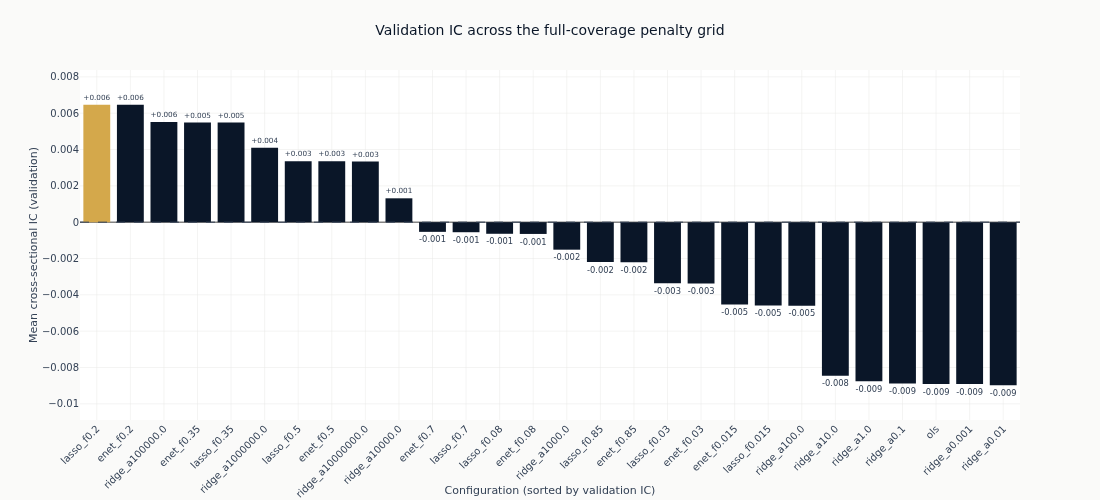

In [9]:
def compact(params: str) -> str:
    """Render declared parameters for a label: `alpha=1000000.0` reads as `alpha=1e+06`."""
    return re.sub(r"\d+\.?\d*(?:[eE][+-]?\d+)?", lambda m: f"{float(m.group()):g}", params)


full = catalog.filter("full_coverage")
leader = full.row(0, named=True)

fig_ic = go.Figure(
    go.Bar(
        x=full.get_column("config_name").to_list(),
        y=full.get_column("ic_mean").to_list(),
        marker_color=[
            COLORS["amber"] if name == leader["config_name"] else COLORS["blue"]
            for name in full.get_column("config_name")
        ],
        text=[f"{value:+.3f}" for value in full.get_column("ic_mean")],
        textposition="outside",
        cliponaxis=False,
    )
)
fig_ic.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig_ic.update_layout(
    title="Validation IC across the full-coverage penalty grid",
    height=500,
    width=1100,
    showlegend=False,
    margin=dict(t=70),
)
fig_ic.update_xaxes(title_text="Configuration (sorted by validation IC)", tickangle=-45)
fig_ic.update_yaxes(title_text="Mean cross-sectional IC (validation)")
show_plotly_with_alt(
    fig_ic,
    "Bar chart of mean validation information coefficient for every full-coverage linear "
    f"configuration, sorted descending, against a dashed zero line. {leader['config_name']} "
    f"({compact(leader['params'])}) is highlighted in amber at the top of the ranking at IC "
    f"{leader['ic_mean']:+.3f}. The configurations span both sides of zero.",
)

### What shrinkage does on its own

The bar chart mixes three estimators. Tracing IC across the Ridge penalty alone isolates the
effect of shrinkage, with the estimator, the features and the folds all held fixed and only
`alpha` moving. The alpha is read from each configuration's declared parameters rather than
parsed out of its name, so the curve plots what was fitted.

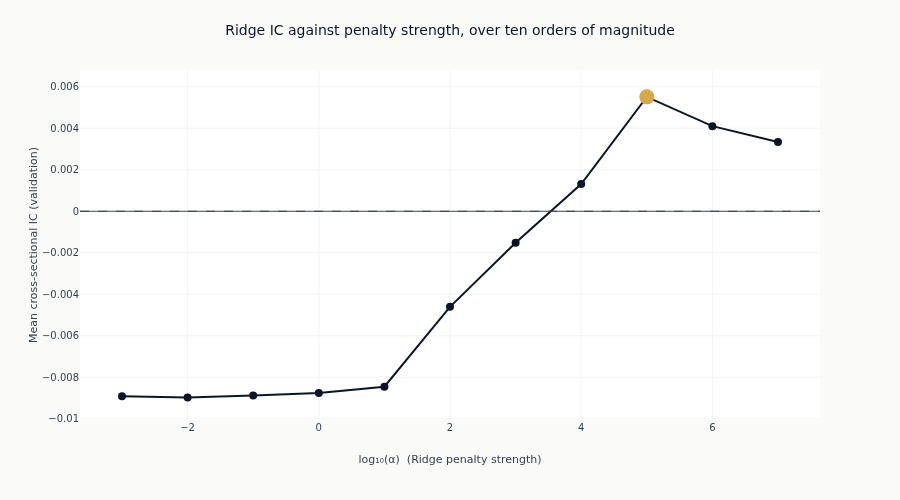

In [10]:
ridge = (
    catalog.filter(pl.col("model_class") == "Ridge")
    .with_columns(
        alpha=pl.col("params").str.extract(r"alpha=([0-9.eE+-]+)").cast(pl.Float64),
    )
    .drop_nulls("alpha")
    .sort("alpha")
)
if ridge.height:
    log_alpha = np.log10(ridge.get_column("alpha").to_numpy())
    ridge_ic = ridge.get_column("ic_mean").to_numpy()
    peak = int(np.argmax(ridge_ic))

    fig_alpha = go.Figure(
        go.Scatter(
            x=log_alpha,
            y=ridge_ic,
            mode="lines+markers",
            line=dict(color=COLORS["blue"], width=2),
            marker=dict(size=8, color=COLORS["blue"]),
        )
    )
    fig_alpha.add_trace(
        go.Scatter(
            x=[log_alpha[peak]],
            y=[ridge_ic[peak]],
            mode="markers",
            marker=dict(size=15, color=COLORS["amber"]),
            showlegend=False,
        )
    )
    fig_alpha.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
    fig_alpha.update_layout(
        title="Ridge IC against penalty strength, over ten orders of magnitude",
        height=500,
        width=900,
        showlegend=False,
        margin=dict(t=70),
    )
    fig_alpha.update_xaxes(title_text="log₁₀(α)  (Ridge penalty strength)", zeroline=False)
    fig_alpha.update_yaxes(title_text="Mean cross-sectional IC (validation)")
    show_plotly_with_alt(
        fig_alpha,
        "Line chart of mean validation information coefficient against the base-ten logarithm of the "
        "Ridge penalty, against a dashed zero line. The curve starts below zero at weak penalties, "
        f"rises through zero as the penalty strengthens to a maximum at 1e{int(round(log_alpha[peak]))} "
        "marked in amber, then eases back.",
    )
else:
    print(
        f"{LABEL} declares no Ridge configurations, so there is no penalty sweep to trace. "
        f"Which estimators this section can show is decided by the menu at "
        f"config/training/{LABEL}.yaml."
    )

## 5. What to notice

**Shrinkage moves this fit from the wrong side of zero to the right side of it.** The
unregularized fit and the weakly penalized Ridge configurations rank the cross-section
backwards; the ranking crosses zero somewhere in the middle of the penalty range and reaches its
maximum well up the grid. That shape has a clear reading. The design matrix lets an unpenalized
fit chase relationships in the training window that reverse out of it, and a negative
out-of-sample IC is what a reversed relationship looks like. Each order of magnitude of penalty
removes more of that, and what is left at the top of the curve is small and positive.

**Small and positive is the honest description.** Nothing in this grid reaches an information
coefficient of the size a working equity cross-sectional signal posts, and the spread between
the top of the grid and the bottom is itself a few thousandths. A notebook that reported only
the top row would be describing the least bad member of a narrow set; the comparison that
matters is against zero, and the margin above it is thin.

**Every configuration scored every date, and that is worth noticing.** In case studies whose
feature sets are more redundant, the most aggressive L1 settings zero all but a couple of
columns, predict a near-constant value on some dates and drop out of the average there, so their
IC is measured on a smaller sample than their neighbours'. That did not happen here: the
coverage column is uniform across the grid, so every number in the table is an average over the
same dates and the ranking can be read directly.

**A penalty cannot fix a dependent cross-section.** The `alpha` sweep addresses collinearity
among the columns of the design matrix. It does nothing about the fact that the rows being
ranked are 20 quotes among eight currencies: a prediction that ranks every USD pair the same way
on a given day is one bet expressed 20 times, and a rank correlation counts it 20 times. That is
a property of the universe rather than of the model, it is not visible in an IC, and it is why
`13_backtest` puts these predictions through a portfolio rather than reading the ranking as a
result.

**None of this selects anything.** IC measures whether predictions rank pairs correctly, not
whether a strategy trading them makes money after costs and turnover. Those are different
questions and a configuration can win the first while losing the second: a signal that ranks
well but reorders the portfolio at every rebalance can lose its edge to trading costs.
Selection is on validation backtest Sharpe over the population this notebook just published,
and it happens in [`13_backtest`](13_backtest.ipynb).

**Known limitations.** The IC here is an average of daily rank correlations, and at a one-day
horizon the overlap problem that longer labels create does not arise - but the dependence among
the pairs does, and it inflates the effective sample in the opposite direction from what a naive
standard error assumes. The grid is a one-dimensional sweep of penalty strength at fixed
features and fixed folds, so it says nothing about interactions between the penalty and either.
And every number here is measured on the validation folds, which have been read many times over
by the time a case study reaches this notebook.

**Next**: [`07_gbm`](07_gbm.ipynb) asks whether gradient boosting finds structure a linear model
cannot represent at all - in particular whether the carry and momentum columns interact, which a
linear model can only see if someone multiplies them together first.